In [3]:
import pandas as pd
import numpy as np
from scipy.io import arff
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, TimeDistributed, Lambda
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
path = '..../KDDTrain+.arff'
data, meta = arff.loadarff(path)
df = pd.DataFrame(data)
for col in df.select_dtypes([object]):
    df[col] = df[col].str.decode('utf-8')
df['label'] = (df[df.columns[-1]] != 'normal').astype(int)

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct.round(2)
})

missing_cols = missing_df[missing_df['Missing Count'] > 0]

if missing_cols.empty:
    print("No missing values found.")
else:
    print(f"Missing values found in {len(missing_cols)} column(s):\n")
    print(missing_cols.to_string())

print(f"Total rows       : {len(df)}")
print(f"Total columns    : {df.shape[1]}")
print(f"Total missing    : {df.isnull().sum().sum()}")
print(f"Affected columns : {len(missing_cols)}")

No missing values found.
Total rows       : 125973
Total columns    : 43
Total missing    : 0
Affected columns : 0


In [7]:
selected_features = [
    'num_access_files',
    'dst_bytes',
    'dst_host_count',
    'num_compromised',
    'dst_host_same_srv_rate',
    'same_srv_rate',
    'dst_host_srv_count',
    'serror_rate',
    'count',
    'rerror_rate',
    'dst_host_srv_rerror_rate',
    'dst_host_srv_serror_rate',
    'dst_host_rerror_rate',
    'dst_host_same_src_port_rate',
    'dst_host_serror_rate',
    'num_file_creations',
    'srv_count',
    'srv_serror_rate',
    'srv_rerror_rate',
    'srv_diff_host_rate',
    'wrong_fragment',
    'urgent',
    'src_bytes',
    'hot',
    'num_failed_logins'
]

print(f"Total features: {len(selected_features)}")

Total features: 25


In [8]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['protocol_type'] = label_encoder.fit_transform(df['protocol_type'])
df['flag'] = label_encoder.fit_transform(df['flag'])

In [9]:
X = df[selected_features].values
y = df.iloc[:, 42].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]
y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)

In [11]:
# --- JaspenCorrelation Layer ---
class JaspenCorrelation(tf.keras.layers.Layer):
    def call(self, inputs):
        t, r = inputs  # t: (None, feat_dim), r: (None, REF_COUNT, feat_dim)
        t_exp = tf.expand_dims(t, 1)  # (None, 1, feat_dim)
        dot = tf.reduce_sum(t_exp * r, axis=2)  # (None, REF_COUNT)

        sum_t = tf.reduce_sum(t_exp, axis=2)  # (None, 1)
        sum_r = tf.reduce_sum(r, axis=2)      # (None, REF_COUNT)

        n = tf.cast(tf.shape(t)[1], tf.float32)
        corr = (n * dot - sum_t * sum_r) / (tf.sqrt(n * sum_t) * tf.sqrt(n * sum_r) + 1e-8)
        return tf.maximum(corr, 0.0)  # only positive correlation


# --- Data Prep (contoh dummy) ---
# Misal kamu punya X_scaled (normalized), y (label)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

X_train = X_train.reshape(-1, X_train.shape[1], 1)
X_test = X_test.reshape(-1, X_test.shape[1], 1)

SEQ_LEN = X_train.shape[1]
CHANNELS = 1
REF_COUNT = 50
NUM_CLASSES = y_train.shape[1]

# --- Inputs ---
test_input = Input(shape=(SEQ_LEN, CHANNELS), name="test_input")
reference_input = Input(shape=(REF_COUNT, SEQ_LEN, CHANNELS), name="reference_input")

# --- Shared CNN ---
shared_cnn = tf.keras.Sequential([
    Conv1D(64, 3, activation='relu'),
    MaxPooling1D(2),
    Conv1D(128, 3, activation='relu'),
    MaxPooling1D(2),
    Flatten()
], name='shared_cnn')

# Apply shared CNN
test_encoded = shared_cnn(test_input)  # (None, feat_dim)
reference_encoded = TimeDistributed(shared_cnn)(reference_input)  # (None, REF_COUNT, feat_dim)

# --- Correlation ---
corr = JaspenCorrelation()([test_encoded, reference_encoded])  # (None, REF_COUNT)
agg = Lambda(lambda x: tf.reduce_mean(x, axis=1, keepdims=True))(corr)  # (None, 1)

# --- Dense Output ---
x = Dense(128, activation='relu')(agg)
output = Dense(NUM_CLASSES, activation='sigmoid')(x)

model = Model(inputs=[test_input, reference_input], outputs=output)

# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ test_input          │ (None, 25, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reference_input     │ (None, 50, 25, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_cnn          │ (None, 512)       │     24,960 │ test_input[0][0]  │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 50, 512)   │     24,960 │ reference_input[… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ jaspen_correlation  │ (None, 50)        │          0 │ shared_cnn[0][0], │
│ (JaspenCorrelation) │                   │            │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1)         │          0 │ jaspen_correlati… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │        256 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 2)         │        258 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,474 (99.51 KB)

 Trainable params: 25,474 (99.51 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
import time,tracemalloc
# Ambil 100 referensi acak dari training set
reference_set = X_train[:REF_COUNT]  # (10, SEQ_LEN, 1)
reference_input_train = np.repeat(reference_set[np.newaxis, :, :, :], X_train.shape[0], axis=0)
reference_input_test = np.repeat(reference_set[np.newaxis, :, :, :], X_test.shape[0], axis=0)
start = time.time()
tracemalloc.start()
# Train
history = model.fit(
    [X_train, reference_input_train],
    y_train,
    validation_data=([X_test, reference_input_test], y_test),
    epochs=10,
    batch_size=32
)
end = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

Epoch 1/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 111s 23ms/step - accuracy: 0.9408 - loss: 0.1740 - val_accuracy: 0.9636 - val_loss: 0.1147
Epoch 2/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - accuracy: 0.9628 - loss: 0.1111 - val_accuracy: 0.9672 - val_loss: 0.1028
Epoch 3/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - accuracy: 0.9655 - loss: 0.1001 - val_accuracy: 0.9675 - val_loss: 0.0940
Epoch 4/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 47s 15ms/step - accuracy: 0.9670 - loss: 0.0883 - val_accuracy: 0.9704 - val_loss: 0.0812
Epoch 5/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - accuracy: 0.9694 - loss: 0.0805 - val_accuracy: 0.9650 - val_loss: 0.0802
Epoch 6/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - accuracy: 0.9714 - loss: 0.0755 - val_accuracy: 0.9670 - val_loss: 0.0781
Epoch 7/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - accuracy: 0.9716 - loss: 0.0726 - val_accuracy: 0.9737 - val_loss: 0.0693
Epoch 8/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 46s 15ms/step - accuracy: 0.9732 

In [13]:
test_loss, test_accuracy = model.evaluate([X_test, reference_input_test], y_test)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")


788/788 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9723 - loss: 0.0655
Test Loss: 0.0655, Test Accuracy: 0.9723


In [14]:
print(f"\nTraining time: {end - start:.2f} seconds")
print(f"Memory usage: Current = {current / 10**6:.2f} MB; Peak = {peak / 10**6:.2f} MB")


Training time: 520.82 seconds
Memory usage: Current = 18.36 MB; Peak = 1030.21 MB


In [15]:
y_pred = model.predict([X_test, reference_input_test])


788/788 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step


In [16]:
y_pred_binary = (y_pred > 0.5).astype(int)


In [17]:
y_true_binary = y_test.astype(int)
cm = confusion_matrix(y_true_binary.flatten(), y_pred_binary.flatten())
TN, FP, FN, TP = cm.ravel()
specificity = TN / (TN + FP + 1e-8)
print(f"Specificity: {specificity:.4f}")

Specificity: 0.9723


In [18]:
y_pred = model.predict([X_test, reference_input_test])
y_pred_binary = (y_pred > 0.5).astype(int)

if y_test.shape[1] > 1:
    y_test_binary = np.argmax(y_test, axis=1)
    y_pred_binary = np.argmax(y_pred_binary, axis=1)

precision = precision_score(y_test_binary, y_pred_binary, average='binary')
recall = recall_score(y_test_binary, y_pred_binary, average='binary')
f1 = f1_score(y_test_binary, y_pred_binary, average='binary')


print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


788/788 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
Precision: 0.9890
Recall: 0.9512
F1-Score: 0.9697


In [19]:

eval_start = time.time()
test_loss, test_accuracy = model.evaluate([X_test, reference_input_test], y_test)
eval_end = time.time()
pred_start = time.time()
y_pred = model.predict([X_test, reference_input_test])
pred_end = time.time()

print(f"Evaluation time: {eval_end - eval_start:.2f} seconds")
pred_start = time.time()
y_pred = model.predict([X_test, reference_input_test])
pred_end = time.time()

print(f"Prediction time: {pred_end - pred_start:.2f} seconds")

788/788 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9723 - loss: 0.0655
788/788 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Evaluation time: 3.79 seconds
788/788 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Prediction time: 3.04 seconds


In [20]:
print(f"Training time: {end - start:.2f} seconds")
print(f"Evaluation time: {eval_end - eval_start:.2f} seconds")
print(f"Prediction time: {pred_end - pred_start:.2f} seconds")
print(f"Total time: {(end - start) + (eval_end - eval_start) + (pred_end - pred_start):.2f} seconds")

Training time: 520.82 seconds
Evaluation time: 3.79 seconds
Prediction time: 3.04 seconds
Total time: 527.66 seconds


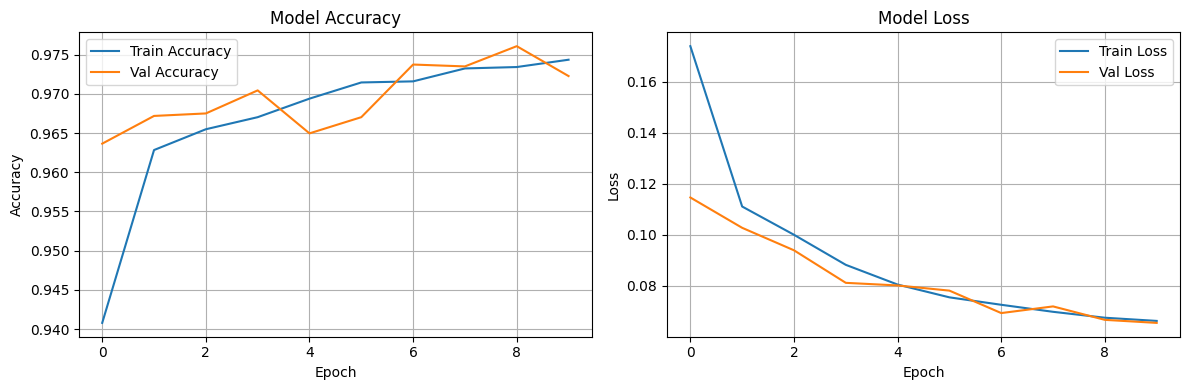

In [21]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()